# Hi-Resolution Single-Input Architecture Comparison

### DenseNet121 vs ResNet-50 vs EfficientNet-B2 vs VGG-16

The same four architectures as `architecture_comparison.ipynb`, trained under the **deployable**
constraint and at a resolution where the lesion is actually visible.

---

## The constraint

> At inference the model receives **only the full mammogram**.

The dual-input baseline in `architecture_comparison.ipynb` reaches 77.9% (DenseNet121), but its
second input is a *cropped lesion patch cut from the radiologist's ground-truth ROI annotation*.
That annotation does not exist for an unseen mammogram, so that model cannot be deployed and its
accuracy is not a screening result. Quantifying this gap is one of the contributions of this work.

The crop and the ROI mask are therefore training-time signals only:

| signal | how it reaches the model | needed at inference? |
|---|---|---|
| full mammogram | the sole input | **yes** |
| cropped lesion patch | frozen dual-input teacher's soft labels (distillation) | no |
| ROI mask | auxiliary segmentation decoder on the shared backbone | no |

## Why this run differs from the earlier single-input attempt

The 224-resolution single-input models plateaued at 65.6-69.6%. Two measurements found the cause,
and it was **not** the training recipe:

1. **The lesion was too small to see.** Source mammograms are ~3024x5063 px with a median lesion
   bounding box of 275x269 px. Resized to a square 224x224 cache that becomes **19x10 px** -- while
   DenseNet121's feature grid at 224 is 7x7, each cell covering 32x32 px. *The median lesion was
   smaller than one feature cell.* The 10th-percentile lesion was 8x5 px.
2. **The recipe was already optimal.** Experiment 2's six-phase search over learning rate, weight
   decay, scheduler, augmentation, loss and optimizer re-selected the untuned baseline every time
   (identical val loss 0.451265). Cosine, OneCycle, Adam, SGD, class-weighted CE and focal loss all
   scored worse.

So this changes the **input representation**, not the hyperparameters:

| | earlier single-input | this notebook |
|---|---|---|
| cache | 224 x 224, square | **384 x 640, aspect preserved** |
| aspect | squashed ~1.7x vertically | padded, undistorted |
| median lesion | 19 x 10 px | **35 x 34 px** (6.1x area) |
| feature grid | 7 x 7 | **20 x 12** |
| batch size | 16 | 8 (VRAM limit) |

Aspect matters as much as resolution: mammograms are ~0.60 w/h, so the square resize was
compressing every lesion vertically by ~1.7x -- an essentially circular 275x269 px lesion became
19x10. Padding is black, which mammogram background already is, so it adds no artifact.

This also sets the **explanation** resolution: Grad-CAM's heatmap resolution *is* the feature grid.
At 7x7 with a sub-cell lesion it could not localize anything even in principle. At 20x12 it can.

## Comparability warning

Batch size differs (8 vs 16), the split differs slightly (2510/317/319 vs 2513/317/320, after four
rows were dropped where CBIS-DDSM's mask dimensions genuinely disagree with the scan), and teacher
logits are now precomputed. **Treat the 224 numbers as context, not a controlled comparison.**
Controlled claims come from comparing runs *within* this notebook, which share every setting.

Sections 1-5 document each component and print its **real source** via `inspect.getsource`, so the
documentation cannot drift from the code that runs.

In [1]:
import inspect, os, sys, time, traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch import optim

sys.path.insert(0, os.path.abspath("../common"))
import hires_lib as H

RESULTS, CKPTS = "results", "checkpoints"
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(CKPTS, exist_ok=True)


def show(obj):
    """Print an object's real source so the documentation cannot drift from the implementation."""
    print(inspect.getsource(obj))


print("torch", torch.__version__, "| CUDA", torch.cuda.is_available(), "| device", H.DEVICE)
print(f"input {H.HIRES_W} x {H.HIRES_H} (W x H)  |  architectures: {H.ARCHITECTURES}")

torch 2.11.0+cu128 | CUDA True | device cuda
input 384 x 640 (W x H)  |  architectures: ['densenet121', 'resnet50', 'efficientnet_b2', 'vgg16']


## 1. Configuration

Inherited from the Experiment 1/2 recipe so that resolution is the variable under test, with two
documented exceptions.

**Batch size 16 -> 8.** Measured peak VRAM at 384x640 on an idle GPU: DenseNet121 2.64 GB,
EfficientNet-B2 2.52 GB, VGG-16 1.88 GB, ResNet-50 1.86 GB, against 4.96 GB free. DenseNet121 at
batch 16 would need ~5.3 GB and would not fit.

**pin_memory False.** Measured ~210 MB of page-locked host RAM vs ~50 MB without. On a 7.2 GB
machine that often has under 1 GB free, page-locked memory (which cannot be paged out) is the worst
thing to hold, and with `num_workers=0` (forced on Windows) it buys nothing.

`weight_decay` stays 1e-4, matching the recorded baselines; Experiment 2 preferred 1e-5 but it
*tied* on validation loss, so continuity wins.

In [2]:
for k in ["SEED", "HIRES_W", "HIRES_H", "BATCH_SIZE", "NUM_WORKERS", "PIN_MEMORY",
          "HEAD_WARMUP_EPOCHS", "MAX_EPOCHS", "EARLY_STOPPING_PATIENCE",
          "DISTILL_TEMPERATURE", "DISTILL_ALPHA", "SEG_LOSS_WEIGHT", "SEG_BIAS_INIT"]:
    print(f"  {k:26s} {getattr(H, k)}")
print(f"  {'BASELINE':26s} {H.BASELINE}")

dfs = {s: pd.read_csv(os.path.join(H.DF_DIR, f"{s}_df_hires.csv"))
       for s in ("train", "val", "test")}
for s, d in dfs.items():
    print(f"  {s:5s} n={len(d):5d}   malignant {d[H.LABEL_COL].apply(H.encode_label).mean():.4f}")
_p = dfs["test"][H.LABEL_COL].apply(H.encode_label).mean()
print(f"\nmajority-class floor on test: {max(_p, 1 - _p):.4f}  (any honest result must beat this)")

  SEED                       42
  HIRES_W                    384
  HIRES_H                    640
  BATCH_SIZE                 8
  NUM_WORKERS                0
  PIN_MEMORY                 False
  HEAD_WARMUP_EPOCHS         5
  MAX_EPOCHS                 40
  EARLY_STOPPING_PATIENCE    8
  DISTILL_TEMPERATURE        4.0
  DISTILL_ALPHA              0.5
  SEG_LOSS_WEIGHT            0.3
  SEG_BIAS_INIT              -5.5
  BASELINE                   {'head_lr': 0.0001, 'backbone_lr': 1e-05, 'weight_decay': 0.0001, 'scheduler': 'plateau'}
  train n= 2510   malignant 0.4151
  val   n=  317   malignant 0.4196
  test  n=  319   malignant 0.4326

majority-class floor on test: 0.5674  (any honest result must beat this)


## 2. Data and paired augmentation

`build_hires_cache.py` scales each image to fit 384x640 preserving aspect, then centre-pads onto a
black canvas. The **identical geometry** is applied to the ROI mask (NEAREST instead of LANCZOS, so
the mask stays strictly binary). Alignment was verified by confirming the lesion always lands on
bright tissue and never on padding.

The segmentation loss compares the decoder's output to the mask **pixel by pixel**, so image and
mask must share the *same* random draw. Independent draws would not merely be suboptimal -- they
would corrupt the target, teaching the decoder to predict a mask that does not match the image it
was shown.

In [3]:
show(H.fit_pad_geometry)
show(H.paired_geometric_augment)
show(H.HiResDataset)

def fit_pad_geometry(orig_w: int, orig_h: int, tw: int = HIRES_W, th: int = HIRES_H):
    """The exact geometry build_hires_cache.fit_pad applied. Deterministic in the source size,
    which is what makes the Grad-CAM inverse possible."""
    s = min(tw / orig_w, th / orig_h)
    nw, nh = max(1, round(orig_w * s)), max(1, round(orig_h * s))
    return nw, nh, (tw - nw) // 2, (th - nh) // 2

def paired_geometric_augment(full_img, mask_img):
    """One random draw shared by image and mask. The segmentation loss is a pixel-wise comparison,
    so independent draws would corrupt the target outright. TF.rotate defaults to NEAREST, matching
    RandomRotation(15)'s default and keeping the mask strictly binary."""
    if random.random() < 0.5:
        full_img, mask_img = TF.hflip(full_img), TF.hflip(mask_img)
    angle = transforms.RandomRotation.get_params([-15, 15])
    return TF.rotate(full_img, angle), TF.rotate(mask_img, angle)

class HiResDataset(Dataset):
    """Returns (full_hires, m

## 3. Teacher: precomputed soft labels

Distillation transfers what the dual-input teacher learned -- including information derived from the
lesion crop -- into a model that never sees a crop. The teacher stays at 224: retraining it at
hi-res would need a second crop cache and would confound the variable under test.

Its logits are computed **once** and cached rather than run inside the training loop, which halves
the image decodes per sample and keeps a second model off the GPU. The trade-off is that soft
labels correspond to the un-augmented view -- standard practice, arguably more stable, and applied
identically to every arm.

**Verification gate:** the teacher must reproduce its recorded score before any run consumes its
logits, or the loading path is broken and every distilled run would be silently poisoned.

In [4]:
show(H.compute_teacher_logits)

def compute_teacher_logits(arch, dfs, batch_size=16, check_reference=True):
    """Run the frozen 224 teacher once over every split and cache the logits.

    This removes the teacher from the training loop entirely: two image decodes per sample instead
    of four, and no second model resident on the GPU.

    `check_reference` gates on the teacher reproducing its recorded score. Disable it only for
    truncated splits, where head(n) is not a random sample and the comparison is meaningless.
    """
    os.makedirs(LOGIT_DIR, exist_ok=True)
    path = os.path.join(LOGIT_DIR, f"teacher_logits_{arch}.npz")
    if os.path.exists(path):
        z = np.load(path)
        if all(k in z for k in dfs) and all(len(z[k]) == len(dfs[k]) for k in dfs):
            print(f"[teacher] using cached logits: {os.path.basename(path)}")
            return {k: z[k] for k in dfs}
        print("[teacher] cached logits stale (row count mismatch) -- recomputing")

    teacher, out = None, {}
    try:
       

## 4. Models

`build_backbone_spatial` returns the **pre-pool** feature map. This is architecture-specific, not
just "delete the pooling layer": for ResNet-50 the slice must be `children()[:-2]`, because
resnet's own `avgpool` sits before `fc`, so `[:-1]` still returns a collapsed `(B, 2048, 1, 1)`.
That failure is silent -- no exception, just degenerate "spatial" features. `_assert_spatial`
catches it at construction, running under `eval()` and restoring the prior mode so the probe cannot
corrupt pretrained BatchNorm statistics with a zeros input.

**Pooling.** At 384x640 the grid is 20x12 = 240 cells with the lesion in roughly one, so global
average pooling dilutes the lesion ~200x. Worse, 7-12% of cells (up to 54% for narrow images) are
black padding whose fraction varies per image, so GAP also injects a per-image offset. `gap_gmp`
concatenates average and max pooling: it strictly contains GAP as a subspace so it cannot lose
capacity, adds no hyperparameters, and the max branch is padding-immune.

**Auxiliary decoder.** Three convolutions predicting the ROI mask from the same features the
classifier uses. Training-only -- `forward()` never calls it. It regularizes, and it forces the
backbone to encode lesion *location*, which is what makes Grad-CAM maps lesion-aligned. Its final
bias starts at -5.5 because the measured foreground fraction is ~0.42% (`sigmoid(-5.5) ~= 0.004`);
a naive init produces large unstable gradients against a >99%-background target.

In [5]:
show(H._assert_spatial)
show(H.SingleInputModel)
show(H.distillation_loss)
show(H.seg_loss_fn)

def _assert_spatial(extractor: nn.Module, arch: str, dim: int,
                    hw=(HIRES_H, HIRES_W)) -> tuple:
    """Assert the extractor emits a genuine spatial map -- catches slicing mistakes like resnet50's
    [:-1] (which leaves avgpool in place and silently yields 1x1).

    Runs under eval() and restores the prior mode: a probe forward in train() mode would update the
    backbone's pretrained BatchNorm running stats from a zeros input, corrupting the very weights
    about to be fine-tuned.
    """
    was_training = extractor.training
    extractor.eval()
    try:
        with torch.no_grad():
            shape = tuple(extractor(torch.zeros(1, 3, *hw)).shape)
    finally:
        extractor.train(was_training)
    assert len(shape) == 4 and shape[1] == dim and shape[-1] > 1 and shape[-2] > 1, \
        f"{arch}: expected spatial (1, {dim}, >1, >1) at {hw}, got {shape}"
    return shape

class SingleInputModel(nn.Module):
    """The deployable student: full mammogram in, c

## 5. Training procedure

Two phases, matching the earlier experiments exactly:

1. **Warm-up (5 epochs)** - backbone frozen, head (and decoder) only. Stops large early gradients
   from a random head wrecking pretrained features.
2. **Fine-tune** - backbone unfrozen, discriminative learning rates (backbone 1e-5, head 1e-4),
   `ReduceLROnPlateau` on validation loss, early stopping at patience 8, checkpoint selection on
   lowest validation loss.

### The trap this guards against

Phase 1 builds its optimizer with `filter(lambda p: p.requires_grad, model.parameters())`, which
picks up every trainable module automatically. Phase 2 builds an **explicit parameter-group list**
for discriminative learning rates -- and that does *not* auto-include anything new. In the earlier
seg-aux experiment this silently froze the segmentation decoder the instant Phase 2 began: no
error, no warning, the decoder simply stopped learning at epoch 6.

`assert_optimizer_complete` compares the optimizer's parameters against everything with
`requires_grad=True` and fails loudly on any omission.

In [6]:
show(H.assert_optimizer_complete)
show(H.run_epoch)

def assert_optimizer_complete(optimizer, model):
    """Every trainable parameter must be in some param group. Catches the 'new module silently
    stops training when Phase 2 begins' class of bug outright."""
    in_opt = {id(p) for g in optimizer.param_groups for p in g["params"]}
    want = {id(p) for p in model.parameters() if p.requires_grad}
    missing = want - in_opt
    assert not missing, f"{len(missing)} trainable params missing from the optimizer"

def run_epoch(model, loader, device, temperature, alpha, seg_weight,
              optimizer=None, scaler=None, desc=""):
    """One pass. Training when `optimizer` is given, evaluation otherwise.

    Also reports how often the student is right where the teacher is wrong, and the reverse. Once
    student_beats_teacher consistently exceeds teacher_beats_student, the student has overtaken its
    teacher and the KL term is pulling it toward the teacher's errors -- the signal to try alpha=0.
    """
    train = optimizer is not No

## 6. Run all four architectures

`ARM` and `POOLING` apply to every architecture in the sweep, so the four remain directly
comparable to one another.

| setting | meaning |
|---|---|
| `ARM = "control"` | distillation only |
| `ARM = "segaux"` | distillation + auxiliary ROI-mask decoder |
| `POOLING = "gap"` | global average pooling (matches the earlier experiments) |
| `POOLING = "gap_gmp"` | average + max concatenated |
| `ALPHA = 0` | no distillation at all -- run this if the student overtakes the teacher |

**Runtime is roughly 1.5-2 h per architecture, so a full sweep is 6-8 h.** `ARCHS` below can be
narrowed to run them one at a time; results append to `results/hires_runs.csv` either way, so the
sweep can be done across several sittings.

Each architecture is trained, evaluated on test, then released with `del` + `free_gpu()` before the
next begins, so peak memory is one model rather than four.

**Watch `S>T` and `T>S`:** the fraction of validation samples the student gets right that the
teacher gets *wrong*, and the reverse. The teacher is ~80% accurate. Once `S>T` consistently
exceeds `T>S`, the student has overtaken it and the KL term is pulling it toward the teacher's
mistakes -- the signal to run `ALPHA = 0`.

In [7]:
ARCHS = H.ARCHITECTURES          # or e.g. ["densenet121"] to do one at a time
ARM = "control"                  # "control" | "segaux"
POOLING = "gap"                  # "gap" | "gap_gmp"
ALPHA = H.DISTILL_ALPHA          # 0 disables distillation
MAX_EPOCHS = H.MAX_EPOCHS
LIMIT = 0                        # >0 truncates every split -- smoke tests only

USE_SEG = ARM == "segaux"
d = {k: (v.head(LIMIT).copy() if LIMIT else v) for k, v in dfs.items()}


def train_one(arch):
    """Full two-phase training for one architecture. Returns (result_row, history_df)."""
    name = f"hires_{ARM}_{POOLING}_a{ALPHA:g}_{arch}"
    ckpt_path = os.path.join(CKPTS, f"{name}.pth")
    print(f"\n{'=' * 78}\n{name}\n{'=' * 78}")

    tl = H.compute_teacher_logits(arch, d, check_reference=not LIMIT) if ALPHA > 0 else None
    train_loader, val_loader, test_loader = H.make_loaders(
        d["train"], d["val"], d["test"], teacher_logits=tl, batch_size=H.BATCH_SIZE)

    H.set_seed(H.SEED)
    model = optimizer = scaler = None
    history, best, best_loss, epoch, bad = [], None, float("inf"), 0, 0
    t0 = time.time()
    try:
        model = H.SingleInputModel(arch, pooling=POOLING, use_seg=USE_SEG).to(H.DEVICE)
        scaler = torch.cuda.amp.GradScaler(enabled=(H.DEVICE.type == "cuda"))

        # ---- Phase 1: warm-up, backbone frozen ----
        model.set_backbone_trainable(False)
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                lr=H.BASELINE["head_lr"], weight_decay=H.BASELINE["weight_decay"])
        H.assert_optimizer_complete(optimizer, model)
        n_warm = min(H.HEAD_WARMUP_EPOCHS, MAX_EPOCHS)

        for phase in (1, 2):
            if phase == 2:
                # ---- Phase 2: unfreeze with discriminative learning rates ----
                model.set_backbone_trainable(True)
                optimizer = optim.AdamW([
                    {"params": model.extractor.parameters(), "lr": H.BASELINE["backbone_lr"]},
                    {"params": model.head_parameters(), "lr": H.BASELINE["head_lr"]},
                ], weight_decay=H.BASELINE["weight_decay"])
                H.assert_optimizer_complete(optimizer, model)   # catches a frozen seg_decoder
                sched = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1,
                                                             patience=5)
            for _ in range(n_warm if phase == 1 else max(MAX_EPOCHS - n_warm, 0)):
                epoch += 1
                tr, trm = H.run_epoch(model, train_loader, H.DEVICE, H.DISTILL_TEMPERATURE, ALPHA,
                                      H.SEG_LOSS_WEIGHT, optimizer, scaler, f"{arch} e{epoch} train")
                va, vam = H.run_epoch(model, val_loader, H.DEVICE, H.DISTILL_TEMPERATURE, ALPHA,
                                      H.SEG_LOSS_WEIGHT, desc=f"{arch} e{epoch} val")
                if phase == 2:
                    sched.step(va["loss"])
                print(f"  [{'warmup' if phase == 1 else '      '}] e{epoch:2d} | "
                      f"train {tr['loss']:.4f} (cls {tr['cls']:.4f} seg {tr['seg']:.4f}) "
                      f"acc {trm['accuracy']:.4f} | val {va['loss']:.4f} acc {vam['accuracy']:.4f} "
                      f"auc {vam['roc_auc']:.4f} | S>T {vam['student_beats_teacher']:.3f} "
                      f"T>S {vam['teacher_beats_student']:.3f}")
                history.append(dict(epoch=epoch, phase=phase, train_loss=tr["loss"],
                                    train_cls=tr["cls"], train_seg=tr["seg"],
                                    val_loss=va["loss"], val_cls=va["cls"], val_seg=va["seg"],
                                    train_acc=trm["accuracy"], val_acc=vam["accuracy"],
                                    val_auc=vam["roc_auc"],
                                    student_beats_teacher=vam["student_beats_teacher"],
                                    teacher_beats_student=vam["teacher_beats_student"]))
                if va["loss"] < best_loss:
                    best_loss, bad = va["loss"], 0
                    best = dict(epoch=epoch, val_loss=va["loss"], val_accuracy=vam["accuracy"],
                                val_auc=vam["roc_auc"])
                    torch.save({"model_state_dict": model.state_dict(), "arch": arch,
                                "pooling": POOLING, "use_seg": USE_SEG,
                                # asserted on load: a 224-trained dict loads here without error
                                # and is silently wrong
                                "input_size": [H.HIRES_H, H.HIRES_W],
                                "alpha": ALPHA, "seed": H.SEED, **best}, ckpt_path)
                elif phase == 2:
                    bad += 1
                    if bad >= H.EARLY_STOPPING_PATIENCE:
                        print(f"  early stop at epoch {epoch}")
                        break

        model.load_state_dict(torch.load(ckpt_path, map_location=H.DEVICE,
                                         weights_only=False)["model_state_dict"])
        _, tem = H.run_epoch(model, test_loader, H.DEVICE, H.DISTILL_TEMPERATURE, ALPHA,
                             H.SEG_LOSS_WEIGHT, desc=f"{arch} test")
        dice = H.seg_dice(model, val_loader, H.DEVICE)
        row = dict(name=name, model=H.ARCH_DISPLAY_NAMES[arch], architecture=arch, arm=ARM,
                   pooling=POOLING, alpha=ALPHA, batch_size=H.BATCH_SIZE, seed=H.SEED,
                   epochs_run=epoch, best_epoch=best["epoch"], best_val_loss=best["val_loss"],
                   best_val_acc=best["val_accuracy"], best_val_auc=best["val_auc"],
                   val_seg_dice=dice, accuracy=tem["accuracy"], roc_auc=tem["roc_auc"],
                   sensitivity=tem["sensitivity"], specificity=tem["specificity"], f1=tem["f1"],
                   train_minutes=round((time.time() - t0) / 60, 1), checkpoint=ckpt_path)
        print(f"  -> test acc {tem['accuracy']:.4f} auc {tem['roc_auc']:.4f} "
              f"in {row['train_minutes']} min")
        return row, pd.DataFrame(history)
    except BaseException:
        # Clear the traceback's frames: they hold the model and optimizer alive, and on this
        # machine a retained failed run is the difference between a retry that works and one that
        # dies with 'bad allocation'.
        traceback.clear_frames(sys.exc_info()[2])
        raise
    finally:
        del model, optimizer, scaler
        H.free_gpu()


rows = []
for arch in ARCHS:
    row, hist = train_one(arch)
    hist.to_csv(os.path.join(RESULTS, f"history_{row['name']}.csv"), index=False)
    rows.append(row)
    runs_csv = os.path.join(RESULTS, "hires_runs.csv")
    pd.concat([pd.read_csv(runs_csv), pd.DataFrame([row])] if os.path.exists(runs_csv)
              else [pd.DataFrame([row])]).to_csv(runs_csv, index=False)

print(f"\nfinished {len(rows)} architecture(s)")


hires_control_gap_a0.5_densenet121
[teacher] using cached logits: teacher_logits_densenet121.npz


C:\Users\Drew\AppData\Local\Temp\ipykernel_24564\2233324151.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(H.DEVICE.type == "cuda"))


densenet121 e1 train:   0%|          | 0/313 [00:00<?, ?it/s]

c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\notebooks\common\hires_lib.py:759: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


densenet121 e1 val:   0%|          | 0/40 [00:00<?, ?it/s]

...

c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\notebooks\common\hires_lib.py:759: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  [      ] e18 | train 0.2649 (cls 0.2649 seg 0.0000) acc 0.8438 | val 0.4010 acc 0.7192 auc 0.8233 | S>T 0.104 T>S 0.151
  early stop at epoch 18


vgg16 test:   0%|          | 0/40 [00:00<?, ?it/s]

c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\notebooks\common\hires_lib.py:759: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  -> test acc 0.7241 auc 0.8325 in 37.3 min

finished 4 architecture(s)


## 7. Comparison table

Against the dual-input baseline (`architecture_comparison_test_metrics.csv`) and the 224
single-input control (`single_input_distillation_ablation_test_metrics.csv`).

`gap_vs_dual_input` is the price of dropping the crop at inference -- **this is the quantity the
thesis is really measuring.** The dual-input column is not a target to beat; it is a model that is
handed the lesion location, and the gap is what localization is worth on CBIS-DDSM.

In [10]:
runs = pd.read_csv(os.path.join(RESULTS, "hires_runs.csv"))
latest = runs.drop_duplicates(subset=["architecture", "arm", "pooling", "alpha"], keep="last")
cur = latest[(latest["arm"] == ARM) & (latest["pooling"] == POOLING) & (latest["alpha"] == ALPHA)]

dual = pd.read_csv(os.path.join(RESULTS, "architecture_comparison_test_metrics.csv"))
p224 = os.path.join(RESULTS, "single_input_distillation_ablation_test_metrics.csv")
old = pd.read_csv(p224) if os.path.exists(p224) else None

cmp = cur[["architecture", "model", "accuracy", "roc_auc", "sensitivity", "specificity",
           "best_val_acc", "best_val_auc", "val_seg_dice", "best_epoch", "epochs_run"]].rename(
    columns={"accuracy": "hires_acc", "roc_auc": "hires_auc"})
cmp = cmp.merge(dual[["architecture", "accuracy"]].rename(
    columns={"accuracy": "dual_input_acc"}), on="architecture", how="left")
if old is not None:
    cmp = cmp.merge(old[["architecture", "accuracy"]].rename(
        columns={"accuracy": "single_224_acc"}), on="architecture", how="left")
    cmp["gain_vs_224"] = cmp["hires_acc"] - cmp["single_224_acc"]
cmp["gap_vs_dual_input"] = cmp["dual_input_acc"] - cmp["hires_acc"]

pd.set_option("display.width", 240)
print(cmp.to_string(index=False))

print("\ndual-input takes full + ground-truth-derived crop -> NOT deployable.")
print("gap_vs_dual_input measures what lesion localization is worth on this dataset.")
print(f"majority-class floor on test: {max(_p, 1 - _p):.4f}")

   architecture           model  hires_acc  hires_auc  sensitivity  specificity  best_val_acc  best_val_auc  val_seg_dice  best_epoch  epochs_run  dual_input_acc  single_224_acc  gain_vs_224  gap_vs_dual_input
    densenet121     DenseNet121   0.755486   0.838778     0.724638     0.779006      0.712934      0.806473           NaN          19          27        0.779141        0.684049     0.071437           0.023655
       resnet50       ResNet-50   0.711599   0.802126     0.724638     0.701657      0.763407      0.815871           NaN          20          28        0.717791        0.656442     0.055157           0.006193
efficientnet_b2 EfficientNet-B2   0.724138   0.815958     0.731884     0.718232      0.744479      0.829765           NaN          17          25        0.769939        0.674847     0.049291           0.045801
          vgg16          VGG-16   0.724138   0.832493     0.731884     0.718232      0.757098      0.831808           NaN          10          18        0.74539

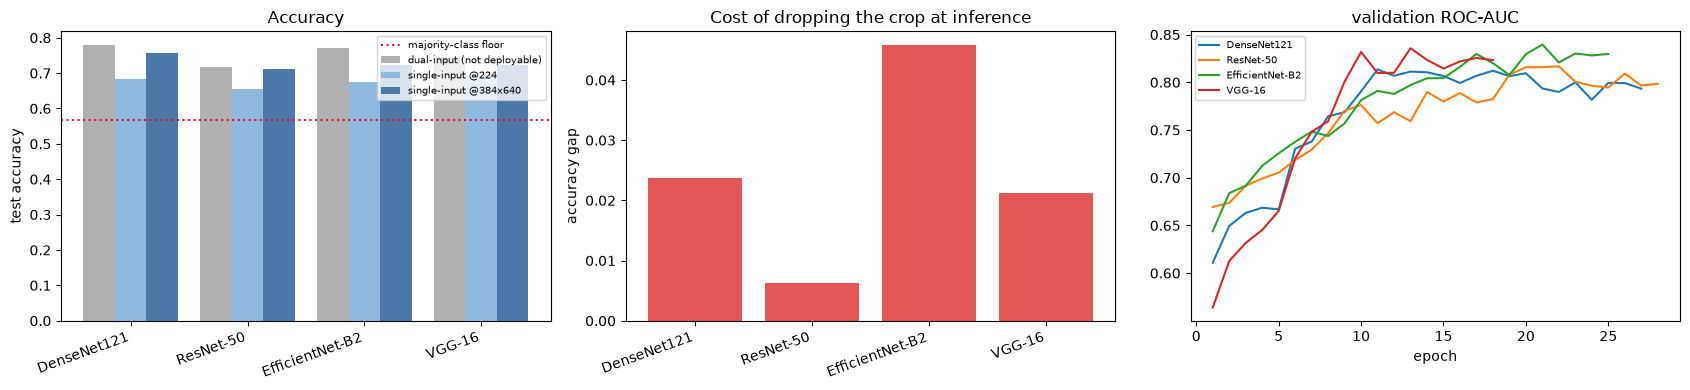

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
x = np.arange(len(cmp))
w = 0.27

axes[0].bar(x - w, cmp["dual_input_acc"], w, label="dual-input (not deployable)", color="#B0B0B0")
if "single_224_acc" in cmp:
    axes[0].bar(x, cmp["single_224_acc"], w, label="single-input @224", color="#8FB8DE")
axes[0].bar(x + w, cmp["hires_acc"], w, label="single-input @384x640", color="#4C78A8")
axes[0].axhline(0.5674, ls=":", c="crimson", label="majority-class floor")
axes[0].set_xticks(x); axes[0].set_xticklabels(cmp["model"], rotation=20, ha="right")
axes[0].set_ylabel("test accuracy"); axes[0].legend(fontsize=7); axes[0].set_title("Accuracy")

axes[1].bar(x, cmp["gap_vs_dual_input"], color="#E45756")
axes[1].set_xticks(x); axes[1].set_xticklabels(cmp["model"], rotation=20, ha="right")
axes[1].set_title("Cost of dropping the crop at inference"); axes[1].set_ylabel("accuracy gap")

for _, r in cur.iterrows():
    f = os.path.join(RESULTS, f"history_{r['name']}.csv")
    if os.path.exists(f):
        h = pd.read_csv(f)
        axes[2].plot(h["epoch"], h["val_auc"], label=r["model"])
axes[2].set_title("validation ROC-AUC"); axes[2].set_xlabel("epoch"); axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, f"hires_comparison_{ARM}_{POOLING}.png"), dpi=110,
            bbox_inches="tight")
plt.show()

## 8. Next

- **Explainability.** `../explainability/gradcam_validation.ipynb` scores any checkpoint written
  here: pointing game, energy concentration, concentration-ratio-vs-chance, IoU curve and pixel AP
  against the ROI masks, with McNemar and Wilcoxon paired tests between two models. It also
  implements the production path, returning the heatmap at the **original image resolution** rather
  than the 384x640 preprocessed size.
- **Arms still to run.** `POOLING = "gap_gmp"`, then `ARM = "segaux"`, then `ALPHA = 0` if the
  student overtakes the teacher. Each appends to `results/hires_runs.csv`, so section 7 accumulates.

### On expectations, for the write-up

The dual-input model reaches 77.9% *while being handed the lesion location*. For a full-image-only
model to reach 85% it would have to beat that by 7 points. At n=319 the standard error on accuracy
is ~2.6 points, so 78% -> 85% is a ~2.7 sigma move: a different-method gap, not a tuning-distance
one. Published full-image CBIS-DDSM results cluster at AUC 0.75-0.85 and accuracy 0.70-0.78.

Four contributions here do not depend on reaching 85%:

1. The widely-reported dual-input result is **not deployable**, and this quantifies by how much.
2. The dual- vs single-input gap on identical splits **measures what lesion localization is worth**.
3. Training-time-only supervision recovers part of that gap while remaining deployable.
4. **Measured** explainability with paired significance tests -- almost no CBIS-DDSM paper
   quantifies its Grad-CAM at all.

Lead with ROC-AUC: threshold-free, comparable across the literature, and lower-variance than
accuracy at this sample size. Report bootstrap 95% CIs (`H.bootstrap_ci`) on headline numbers.